Imports the required libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loads the dataset into a Pandas DataFrame.

In [ ]:
df = pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset.csv")

Checking Rows & Cols

In [ ]:
df.shape

(9994, 11)

Displaying the starting 5 rows for better understanding of structure

In [ ]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


Displays all column names in the dataset.

In [ ]:
df.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

Shows the data type of each column.

In [ ]:
df.dtypes

Order ID          object
Customer Name     object
Category          object
Sub Category      object
City              object
Order Date        object
Region            object
Sales              int64
Discount         float64
Profit           float64
State             object
dtype: object

Checks how many missing values are present in each column.

In [ ]:
df.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Checks whether any completely duplicated records exist.

In [ ]:
df.duplicated().sum()

np.int64(0)

Shows the number of unique values in each column.

In [ ]:
df.nunique()

Order ID         9994
Customer Name      50
Category            7
Sub Category       23
City               24
Order Date       1236
Region              5
Sales            1989
Discount           26
Profit           8380
State               1
dtype: int64

Displays summary statistics for the numerical columns.

In [ ]:
df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


Displays summary statistics for the text columns.

In [ ]:
df.describe(include="object")

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,State
count,9994,9994,9994,9994,9994,9994,9994,9994
unique,9994,50,7,23,24,1236,5,1
top,OD1,Amrish,Snacks,Health Drinks,Kanyakumari,09-05-2017,West,Tamil Nadu
freq,1,227,1514,719,459,38,3203,9994


Checks whether every Order ID is unique.

In [ ]:
df["Order ID"].nunique()

9994

Shows how many records belong to each region.

In [ ]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1619
North         1
Name: count, dtype: int64

Shows how many records belong to each state.

In [ ]:
df["State"].value_counts()

State
Tamil Nadu    9994
Name: count, dtype: int64

Shows how many records belong to each product category.

In [ ]:
df["Category"].value_counts()

Category
Snacks               1514
Eggs, Meat & Fish    1490
Fruits & Veggies     1418
Bakery               1413
Beverages            1400
Food Grains          1398
Oil & Masala         1361
Name: count, dtype: int64

Shows how many records belong to each product sub-category.

In [ ]:
df["Sub Category"].value_counts()

Sub Category
Health Drinks         719
Soft Drinks           681
Cookies               520
Breads & Buns         502
Chocolates            499
Noodles               495
Masalas               463
Biscuits              459
Cakes                 452
Edible Oil & Ghee     451
Spices                447
Mutton                394
Eggs                  379
Organic Staples       372
Fresh Fruits          369
Fish                  369
Fresh Vegetables      354
Atta & Flour          353
Chicken               348
Organic Fruits        348
Organic Vegetables    347
Dals & Pulses         343
Rice                  330
Name: count, dtype: int64

Displays sample order dates to inspect their format.

In [ ]:
df["Order Date"].head(20)

0     11-08-2017
1     11-08-2017
2     06-12-2017
3     10-11-2016
4     10-11-2016
5     06-09-2015
6     06-09-2015
7     06-09-2015
8     06-09-2015
9     06-09-2015
10    06-09-2015
11    06-09-2015
12     4/15/2018
13    12-05-2017
14    11/22/2016
15    11/22/2016
16    11-11-2015
17     5/13/2015
18     8/27/2015
19     8/27/2015
Name: Order Date, dtype: object

Converts Order Date from text into a proper datetime data type.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")

Confirms that Order Date was converted successfully.

In [ ]:
df["Order Date"].dtype

dtype('<M8[ns]')

Checks the earliest and latest dates available in the dataset.

In [ ]:
print("Earliest Date:", df["Order Date"].min())
print("Latest Date:", df["Order Date"].max())

Earliest Date: 2015-01-03 00:00:00
Latest Date: 2018-12-30 00:00:00


Checks whether Sales contains zero or negative values.

In [ ]:
df[df["Sales"] <= 0]

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State


Checks the minimum and maximum discount values.

In [ ]:
print("Minimum Discount:", df["Discount"].min())
print("Maximum Discount:", df["Discount"].max())

Minimum Discount: 0.1
Maximum Discount: 0.35


Checks whether any orders have zero or negative profit.

In [ ]:
(df["Profit"] <= 0).sum()

np.int64(0)

## Outlier Analysis

Calculates the IQR limits for Sales.

In [ ]:
sales_q1 = df["Sales"].quantile(0.25)
sales_q3 = df["Sales"].quantile(0.75)
sales_iqr = sales_q3 - sales_q1
sales_lower = sales_q1 - (1.5 * sales_iqr)
sales_upper = sales_q3 + (1.5 * sales_iqr)

print("Lower Limit:", sales_lower)
print("Upper Limit:", sales_upper)

Lower Limit: -492.125
Upper Limit: 3486.875


Counts Sales values that fall outside the IQR limits.

In [ ]:
((df["Sales"] < sales_lower) | (df["Sales"] > sales_upper)).sum()

np.int64(0)

Calculates the IQR limits for Profit.

In [ ]:
profit_q1 = df["Profit"].quantile(0.25)
profit_q3 = df["Profit"].quantile(0.75)
profit_iqr = profit_q3 - profit_q1
profit_lower = profit_q1 - (1.5 * profit_iqr)
profit_upper = profit_q3 + (1.5 * profit_iqr)

print("Lower Limit:", profit_lower)
print("Upper Limit:", profit_upper)

Lower Limit: -338.385
Upper Limit: 1044.035


Counts Profit values that fall outside the IQR limits.

In [ ]:
((df["Profit"] < profit_lower) | (df["Profit"] > profit_upper)).sum()

np.int64(43)

Displays the highest Profit outliers for inspection.

In [ ]:
df[
    (df["Profit"] < profit_lower) |
    (df["Profit"] > profit_upper)
].sort_values("Profit", ascending=False).head(10)

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
3159,OD3160,Haseena,Bakery,Cakes,Cumbum,2017-09-04,Central,2491,0.26,1120.95,Tamil Nadu
3467,OD3468,Verma,Fruits & Veggies,Fresh Fruits,Theni,2015-02-16,Central,2490,0.24,1120.50,Tamil Nadu
3436,OD3437,Yadav,Bakery,Breads & Buns,Theni,2015-12-16,Central,2469,0.29,1111.05,Tamil Nadu
8134,OD8135,Aditi,Bakery,Biscuits,Coimbatore,2016-09-18,East,2452,0.18,1103.40,Tamil Nadu
9782,OD9783,Komal,Snacks,Cookies,Karur,2017-03-29,Central,2450,0.21,1102.50,Tamil Nadu
1115,OD1116,Vinne,"Eggs, Meat & Fish",Chicken,Madurai,2017-07-04,West,2439,0.30,1097.55,Tamil Nadu
4943,OD4944,Willams,Beverages,Soft Drinks,Ramanadhapuram,2018-11-21,Central,2434,0.29,1095.30,Tamil Nadu
1304,OD1305,Akash,Fruits & Veggies,Organic Vegetables,Salem,2017-12-01,East,2432,0.34,1094.40,Tamil Nadu
1807,OD1808,Esther,Bakery,Biscuits,Trichy,2018-11-21,West,2429,0.11,1093.05,Tamil Nadu
3144,OD3145,Sabeela,Oil & Masala,Masalas,Krishnagiri,2017-12-29,Central,2478,0.13,1090.32,Tamil Nadu


The Profit outliers are kept because they are valid high-profit transactions and do not show missing or invalid values.

## Feature Engineering

Creates an Order Year column for yearly analysis.

In [ ]:
df["Order Year"] = df["Order Date"].dt.year

Creates an Order Month column for monthly analysis.

In [ ]:
df["Order Month"] = df["Order Date"].dt.month_name()

Creates a Month Number column so months can be sorted correctly.

In [ ]:
df["Month Number"] = df["Order Date"].dt.month

Creates an Order Quarter column for quarterly analysis.

In [ ]:
df["Order Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)

Calculates the profit margin percentage for each order.

In [ ]:
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

Displays the dataset after feature engineering.

In [ ]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Order Year,Order Month,Month Number,Order Quarter,Profit Margin
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu,2017,November,11,Q4,32.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu,2017,November,11,Q4,20.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu,2017,June,6,Q2,7.0
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu,2016,October,10,Q4,10.0
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu,2016,October,10,Q4,39.0


## Final Data Validation

Checks missing values again after data preparation.

In [ ]:
df.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
Order Year       0
Order Month      0
Month Number     0
Order Quarter    0
Profit Margin    0
dtype: int64

Checks duplicate rows again after data preparation.

In [ ]:
df.duplicated().sum()

np.int64(0)

Checks the final data types after cleaning.

In [ ]:
df.dtypes

Order ID                 object
Customer Name            object
Category                 object
Sub Category             object
City                     object
Order Date       datetime64[ns]
Region                   object
Sales                     int64
Discount                float64
Profit                  float64
State                    object
Order Year                int32
Order Month              object
Month Number              int32
Order Quarter            object
Profit Margin           float64
dtype: object

Checks the final number of rows and columns.

In [ ]:
df.shape

(9994, 16)

Saves the cleaned dataset for Power BI and further analysis.

In [ ]:
df.to_csv("Supermart_Grocery_Cleaned.csv", index=False)

## Part 2 – Exploratory Data Analysis

Shows the yearly Sales trend.

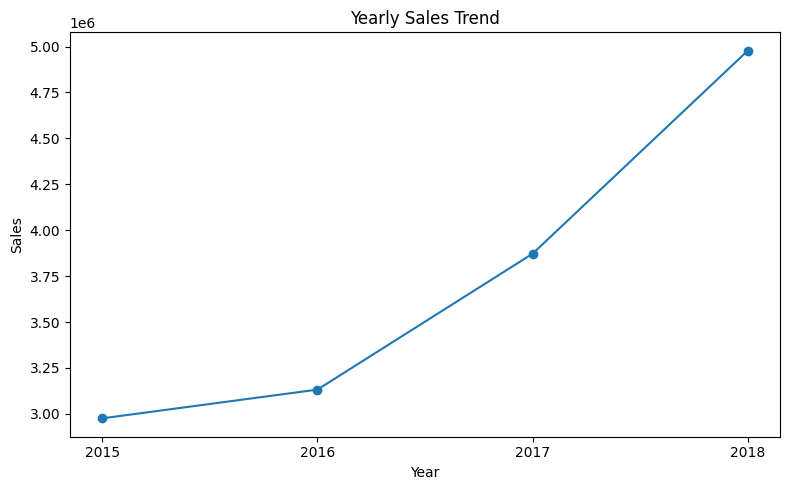

In [ ]:
yearly_sales = df.groupby("Order Year")["Sales"].sum()

plt.figure(figsize=(8, 5))
yearly_sales.plot(marker="o")
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(yearly_sales.index)
plt.tight_layout()
plt.show()

Shows the yearly Profit trend.

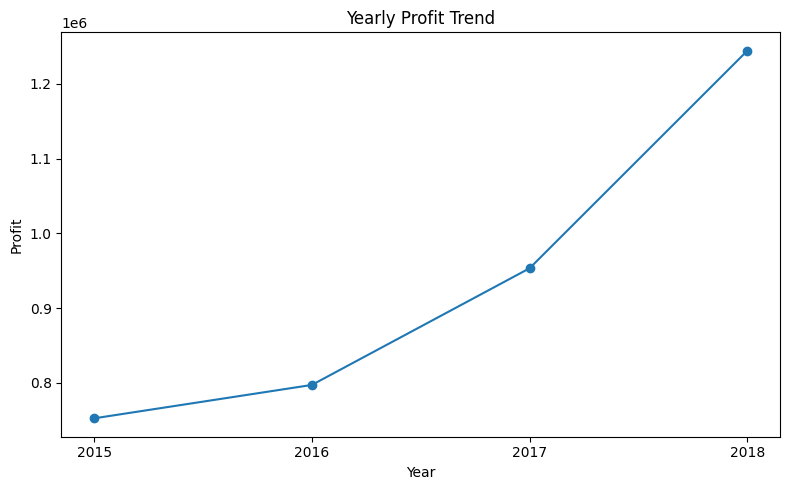

In [ ]:
yearly_profit = df.groupby("Order Year")["Profit"].sum()

plt.figure(figsize=(8, 5))
yearly_profit.plot(marker="o")
plt.title("Yearly Profit Trend")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.xticks(yearly_profit.index)
plt.tight_layout()
plt.show()

Shows total Sales for each month.

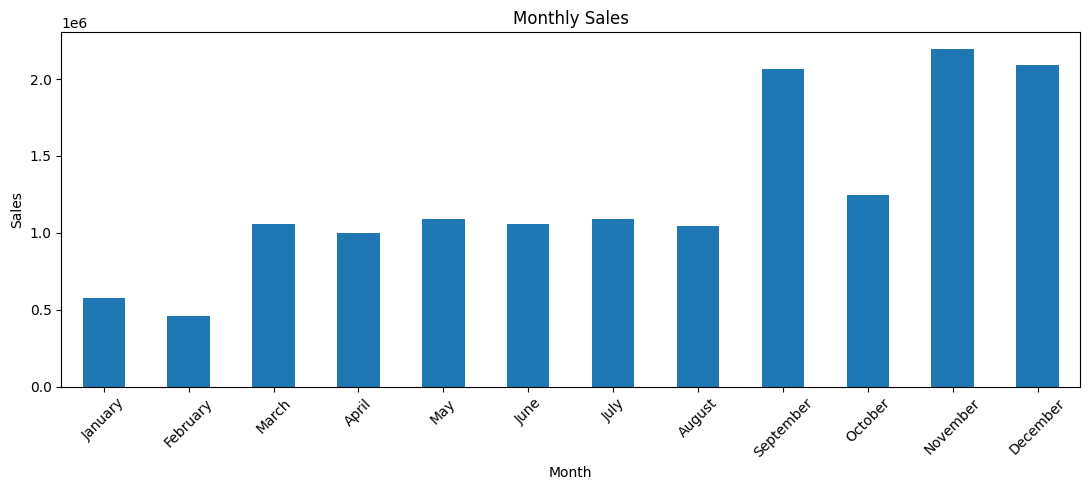

In [ ]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_sales = df.groupby("Order Month")["Sales"].sum().reindex(month_order)

plt.figure(figsize=(11, 5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Shows total Sales for each quarter.

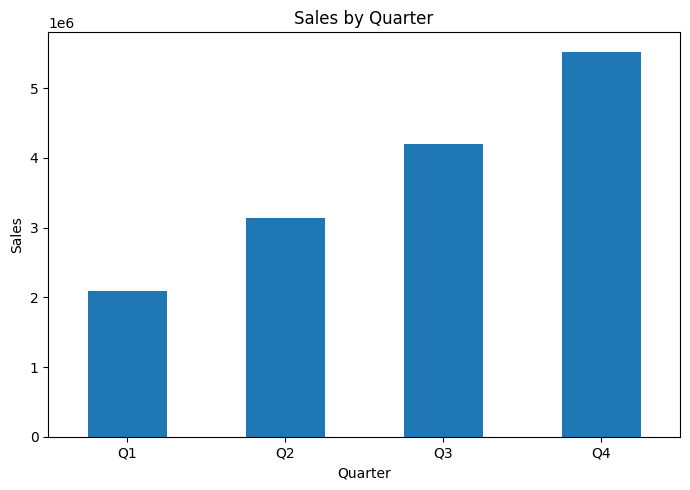

In [ ]:
quarterly_sales = df.groupby("Order Quarter")["Sales"].sum().reindex(["Q1", "Q2", "Q3", "Q4"])

plt.figure(figsize=(7, 5))
quarterly_sales.plot(kind="bar")
plt.title("Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Compares Sales across product categories.

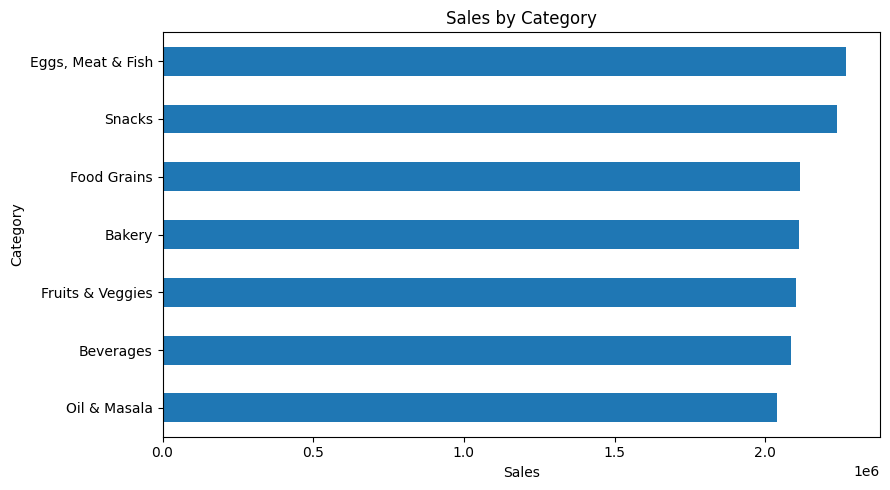

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

plt.figure(figsize=(9, 5))
category_sales.plot(kind="barh")
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Compares Profit across product categories.

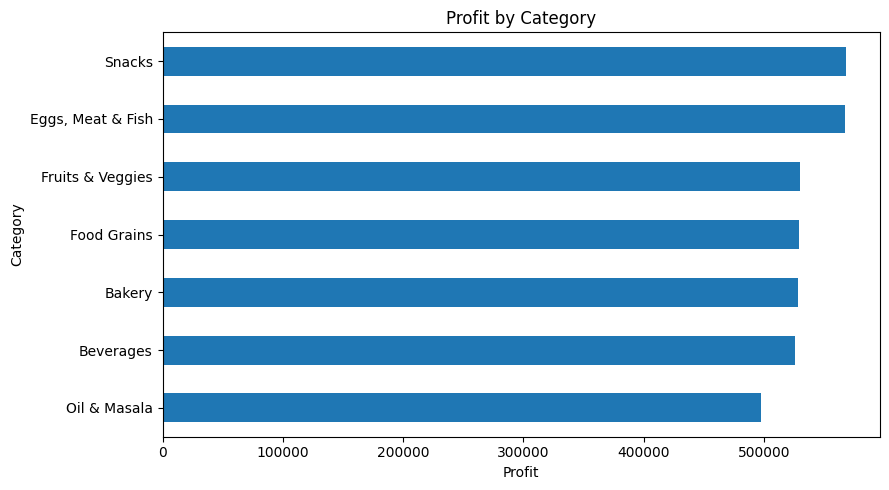

In [ ]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values()

plt.figure(figsize=(9, 5))
category_profit.plot(kind="barh")
plt.title("Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Shows the top 10 sub-categories by Sales.

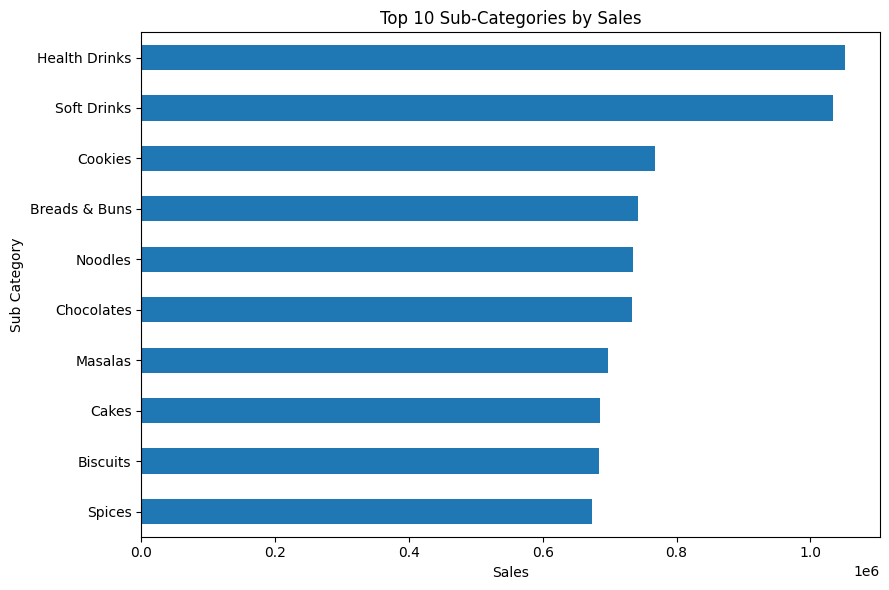

In [ ]:
top_subcategory_sales = df.groupby("Sub Category")["Sales"].sum().nlargest(10).sort_values()

plt.figure(figsize=(9, 6))
top_subcategory_sales.plot(kind="barh")
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Sub Category")
plt.tight_layout()
plt.show()

Shows the top 10 sub-categories by Profit.

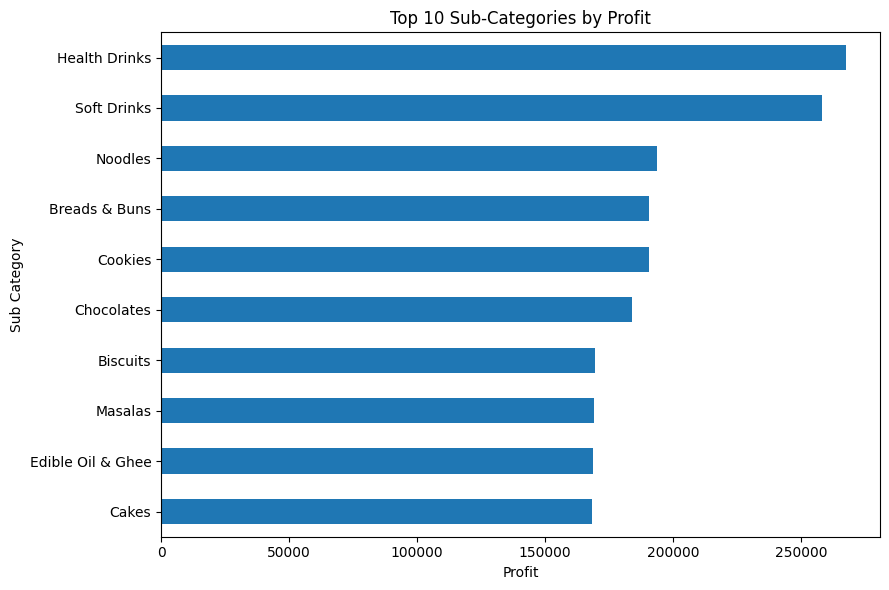

In [ ]:
top_subcategory_profit = df.groupby("Sub Category")["Profit"].sum().nlargest(10).sort_values()

plt.figure(figsize=(9, 6))
top_subcategory_profit.plot(kind="barh")
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Profit")
plt.ylabel("Sub Category")
plt.tight_layout()
plt.show()

Compares Sales across regions.

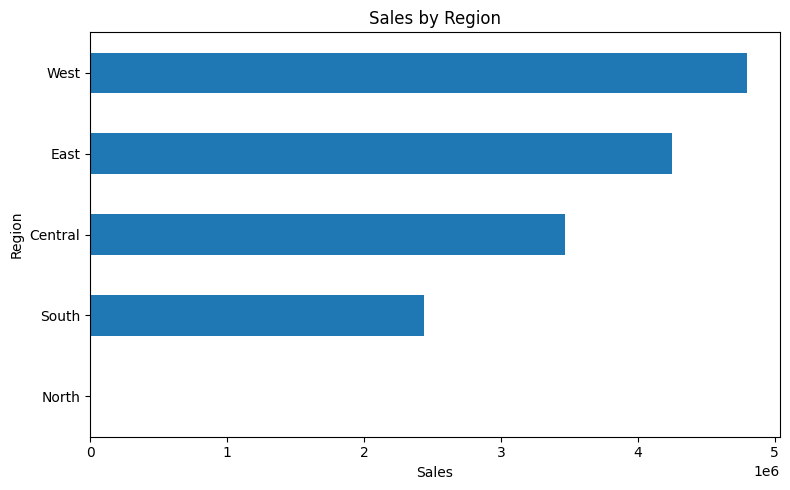

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(8, 5))
region_sales.plot(kind="barh")
plt.title("Sales by Region")
plt.xlabel("Sales")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Compares Profit across regions.

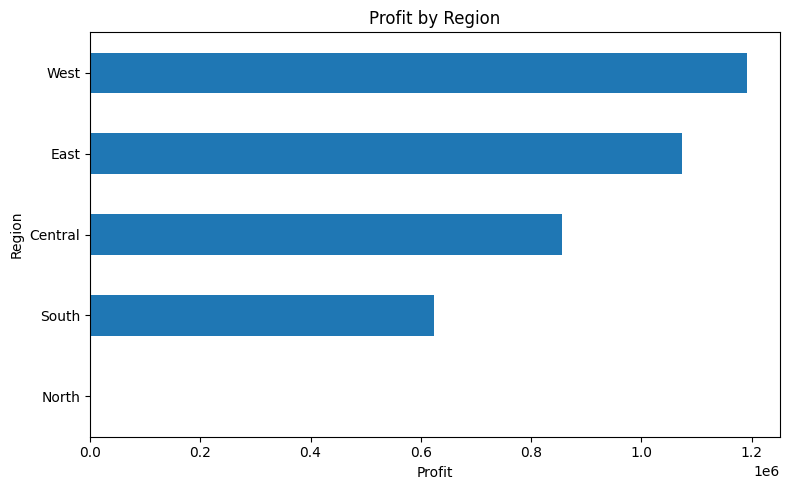

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.figure(figsize=(8, 5))
region_profit.plot(kind="barh")
plt.title("Profit by Region")
plt.xlabel("Profit")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Shows the top 10 cities by Sales.

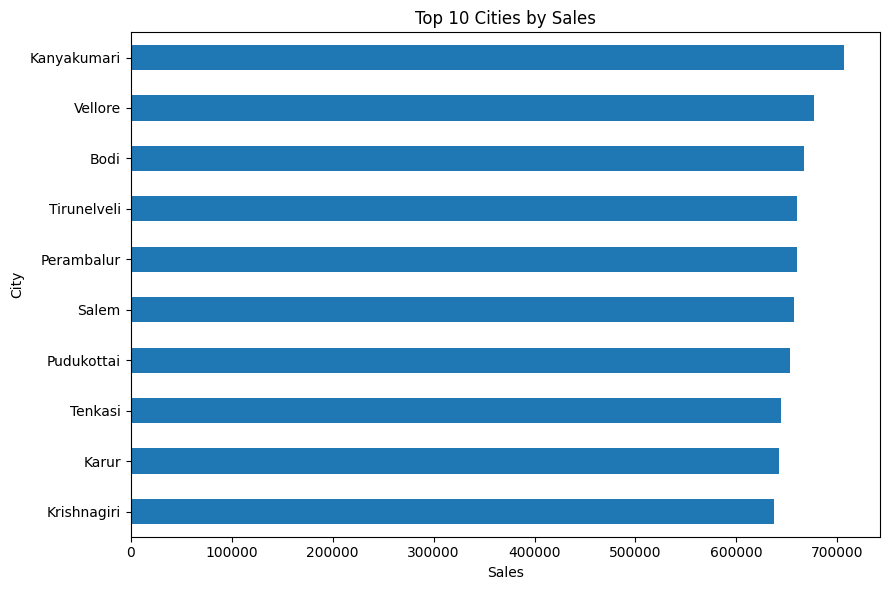

In [ ]:
top_city_sales = df.groupby("City")["Sales"].sum().nlargest(10).sort_values()

plt.figure(figsize=(9, 6))
top_city_sales.plot(kind="barh")
plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

Shows the top 10 customers by Sales.

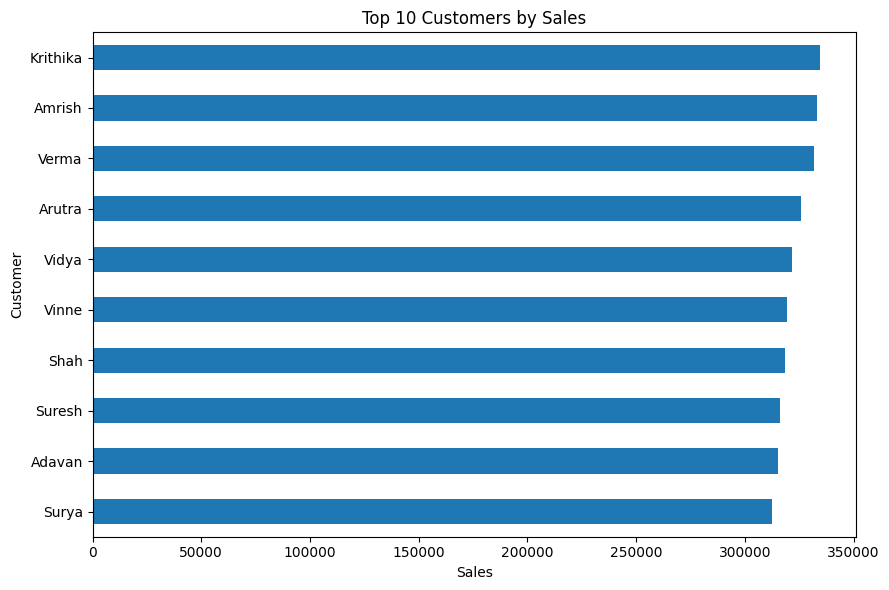

In [ ]:
top_customer_sales = df.groupby("Customer Name")["Sales"].sum().nlargest(10).sort_values()

plt.figure(figsize=(9, 6))
top_customer_sales.plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

Shows the number of orders in each category.

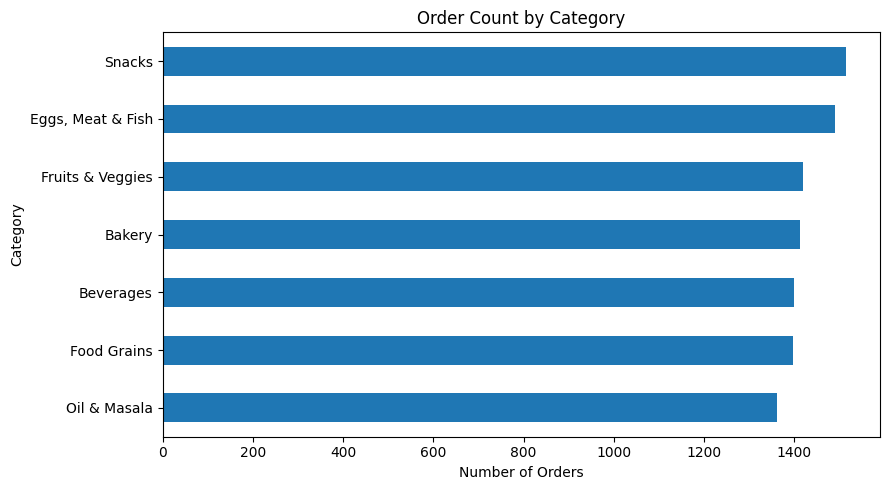

In [ ]:
category_orders = df.groupby("Category")["Order ID"].count().sort_values()

plt.figure(figsize=(9, 5))
category_orders.plot(kind="barh")
plt.title("Order Count by Category")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Shows the relationship between Sales and Profit.

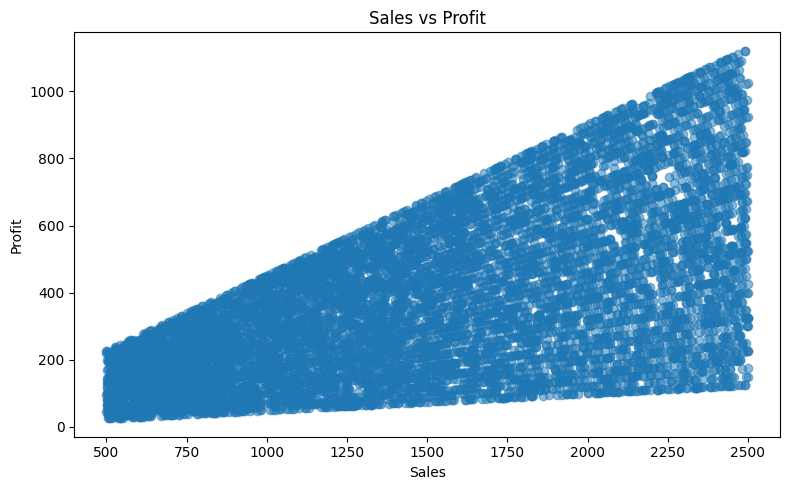

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

Shows the relationship between Discount and Profit.

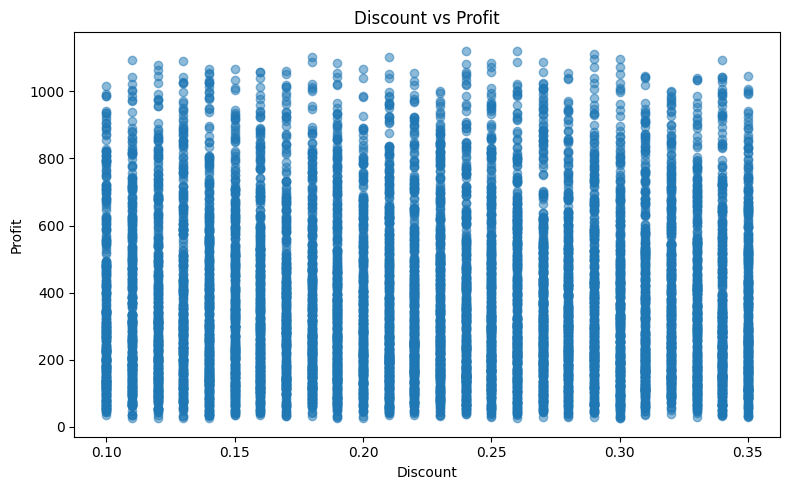

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

## Part 3 – KPI Development

Calculates Total Sales.

In [ ]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 14956982


Calculates Total Profit.

In [ ]:
total_profit = df["Profit"].sum()
print("Total Profit:", round(total_profit, 2))

Total Profit: 3747121.2


Calculates the total number of unique orders.

In [ ]:
total_orders = df["Order ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 9994


Calculates Average Order Value.

In [ ]:
average_order_value = total_sales / total_orders
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 1496.6


Calculates the overall Profit Margin.

In [ ]:
overall_profit_margin = (total_profit / total_sales) * 100
print("Profit Margin (%):", round(overall_profit_margin, 2))

Profit Margin (%): 25.05


Calculates the total number of customers using unique customer names.

In [ ]:
customer_count = df["Customer Name"].nunique()
print("Customer Count:", customer_count)

Customer Count: 50


Calculates Sales Growth from 2017 to 2018.

In [ ]:
sales_by_year = df.groupby("Order Year")["Sales"].sum()
sales_growth = ((sales_by_year.loc[2018] - sales_by_year.loc[2017]) / sales_by_year.loc[2017]) * 100
print("2018 Sales Growth (%):", round(sales_growth, 2))

2018 Sales Growth (%): 28.55
